# Market Returns EW - NYSE P20 Benchmark Creation

## Overview
This Jupyter Notebook creates an equal-weighted market returns benchmark excluding the 20% smallest NYSE firms by market cap. Portfolio formation in May, holding period July to June next year.

## Key Features
- **NYSE Breakpoints**: Computes 20th percentile market cap thresholds annually.
- **EW Returns Calculation**: Equal-weighted returns for eligible stocks above threshold.
- **Data Filtering**: Includes price filter ($5 minimum) and exchange codes.
- **Validation**: Performance stats, drawdowns, correlations, and visualizations.

## Methodology
1. Load processed CRSP and returns data.
2. Compute NYSE P20 thresholds for each year.
3. Calculate EW market returns for holding periods.
4. Save benchmark to Parquet file.
5. Validate with descriptive stats and plots.

## Dependencies
- Libraries: pandas, numpy, matplotlib, pathlib.
- Data: Processed CRSP Parquet, returns Parquet.
- Environment: macOS with VS Code, Python 3.x.

## Usage
1. Update paths and parameters if needed.
2. Run cells sequentially to compute and save benchmark.
3. Review output file and validation plots.

## Output Files
- **data/ml_data/market/market_returns_ew_nys80.parquet**: Parquet file with EW market returns, dates, and metadata.

This notebook generates a custom market benchmark for ML applications, ensuring consistency with academic standards.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [2]:
def compute_nyse_mktcap_breakpoints(backtest_df, percentile=20, start_year=1963, end_year=2024, verbose=True):
    thresholds = []
    for year in range(start_year, end_year + 1):
        if verbose and year % 10 == 0:
            print(f"📅 {year}...", end='\r')
        may_nyse = backtest_df[
            (backtest_df['mthdate'].dt.year == year) &
            (backtest_df['mthdate'].dt.month == 5) &
            (backtest_df['EXCHCD'] == 1)
        ].copy()
        if len(may_nyse) < 10:
            continue
        threshold = may_nyse['mktcap'].quantile(percentile / 100, interpolation='lower')
        thresholds.append({'year': year, 'threshold': threshold})
    thresholds_df = pd.DataFrame(thresholds)
    nyse_thresholds = pd.Series(data=thresholds_df['threshold'].values, index=thresholds_df['year'].values)
    if verbose and len(nyse_thresholds) > 0:
        print(f"\n✅ NYSE P{percentile} calculé : {len(nyse_thresholds)} années ({nyse_thresholds.index.min()}-{nyse_thresholds.index.max()})")
    return nyse_thresholds

def compute_market_ew_returns(backtest_df, nyse_p20_thresholds, start_year=1963, end_year=2024, verbose=True):
    returns_list = []
    for year in range(start_year, end_year):
        if verbose and year % 10 == 0:
            print(f"📅 {year}...", end='\r')
        if year not in nyse_p20_thresholds.index:
            continue
        threshold_p20 = nyse_p20_thresholds.loc[year]
        may_data = backtest_df[
            (backtest_df['mthdate'].dt.year == year) &
            (backtest_df['mthdate'].dt.month == 5) &
            (backtest_df['mktcap'] >= threshold_p20) &
            (backtest_df['EXCHCD'].isin([1, 2, 3]))
        ]
        market_permnos = may_data['PERMNO'].unique().tolist()
        if len(market_permnos) < 5:
            continue
        test_data = backtest_df[
            (backtest_df['PERMNO'].isin(market_permnos)) &
            (((backtest_df['mthdate'].dt.year == year) & (backtest_df['mthdate'].dt.month >= 7)) |
             ((backtest_df['mthdate'].dt.year == year + 1) & (backtest_df['mthdate'].dt.month <= 6)))
        ]
        if len(test_data) == 0:
            continue
        test_returns = test_data.pivot(index='mthdate', columns='PERMNO', values='ret')
        for date in test_returns.index:
            available_permnos = [p for p in market_permnos if p in test_returns.columns]
            if len(available_permnos) == 0:
                continue
            ret_stocks = test_returns.loc[date, available_permnos].dropna()
            ret_market_ew = ret_stocks.mean() if len(ret_stocks) > 0 else np.nan
            returns_list.append({
                'date': date, 'year_formed': year, 'ret_market_ew': ret_market_ew,
                'n_stocks': len(ret_stocks), 'n_eligible': len(market_permnos)
            })
    returns_df = pd.DataFrame(returns_list).sort_values('date').reset_index(drop=True)
    if verbose and len(returns_df) > 0:
        print(f"\n✅ Returns calculés : {len(returns_df):,} obs ({returns_df['date'].min().date()} → {returns_df['date'].max().date()})")
    return returns_df

In [3]:
MIN_PRICE = 5  # ← Paramètre global

print("="*80)
print("🔧 Chargement données")
print("="*80)

# 1. Charger rendements
data_processed = pd.read_parquet('raw_data_processing/data/d_dataset_full/data.parquet', columns=['PERMNO', 'date', 'ret_adj'])
base_df = data_processed.copy()
base_df.rename(columns={'date': 'mthdate', 'ret_adj': 'ret'}, inplace=True)
base_df['mthdate'] = pd.to_datetime(base_df['mthdate'])
base_df = base_df.drop_duplicates(subset=['PERMNO', 'mthdate'], keep='first')
print(f"📂 Base : {len(base_df):,} obs")

# 2. Charger CRSP
crsp_full = pd.read_parquet('raw_data_processing/data/b_processed/crsp_with_delistings.parquet', columns=['PERMNO', 'date', 'PRC', 'SHROUT', 'EXCHCD'])
crsp_full['mthdate'] = pd.to_datetime(crsp_full['date'])
crsp_full['mktcap'] = crsp_full['PRC'].abs() * crsp_full['SHROUT'] / 1000
crsp_full = crsp_full.drop_duplicates(subset=['PERMNO', 'mthdate'], keep='first')

# 3. Merge
backtest_df = base_df.merge(crsp_full[['PERMNO', 'mthdate', 'mktcap', 'EXCHCD', 'PRC']], on=['PERMNO', 'mthdate'], how='left')
del data_processed, base_df, crsp_full

# ✅ NOUVEAU : FILTRE PRIX (COHÉRENCE)
print(f"\n📊 AVANT filtre prix (${MIN_PRICE}) : {len(backtest_df):,} obs")
backtest_df = backtest_df[backtest_df['PRC'].abs() >= MIN_PRICE].copy()
print(f"✅ APRÈS filtre prix : {len(backtest_df):,} obs")

print(f"✅ Panel : {len(backtest_df):,} obs")
print("="*80)

🔧 Chargement données
📂 Base : 4,309,677 obs

📊 AVANT filtre prix ($5) : 4,309,677 obs
✅ APRÈS filtre prix : 3,230,756 obs
✅ Panel : 3,230,756 obs


In [4]:
nyse_p20_thresholds = compute_nyse_mktcap_breakpoints(backtest_df, percentile=20, start_year=1963, end_year=2024, verbose=True)

📅 2020...
✅ NYSE P20 calculé : 62 années (1963-2024)


In [5]:
returns_market_ew = compute_market_ew_returns(backtest_df, nyse_p20_thresholds, start_year=1963, end_year=2024, verbose=True)

📅 2020...
✅ Returns calculés : 732 obs (1963-07-31 → 2024-06-28)


In [6]:
print(f"\n{'='*80}")
print("📊 PORTFOLIO MARKET EW - NYSE P20")
print(f"{'='*80}\n")

print(f"Période : {returns_market_ew['date'].min().date()} → {returns_market_ew['date'].max().date()}")
print(f"Observations : {len(returns_market_ew):,}\n")

print("Statistiques mensuelles:")
print(returns_market_ew['ret_market_ew'].describe())

cum_ret = (1 + returns_market_ew['ret_market_ew'].dropna()).prod() - 1
n_months = len(returns_market_ew['ret_market_ew'].dropna())
annual_ret = (1 + cum_ret) ** (12 / n_months) - 1
annual_vol = returns_market_ew['ret_market_ew'].std() * np.sqrt(12)
sharpe = annual_ret / annual_vol if annual_vol > 0 else 0

print(f"\nAnnualisé:")
print(f"  Return : {annual_ret:.2%}")
print(f"  Vol    : {annual_vol:.2%}")
print(f"  Sharpe : {sharpe:.2f}")

returns_market_ew.head(20)


📊 PORTFOLIO MARKET EW - NYSE P20

Période : 1963-07-31 → 2024-06-28
Observations : 732

Statistiques mensuelles:
count    732.000000
mean       0.011479
std        0.051709
min       -0.259391
25%       -0.018560
50%        0.013755
75%        0.043032
max        0.227783
Name: ret_market_ew, dtype: float64

Annualisé:
  Return : 12.86%
  Vol    : 17.91%
  Sharpe : 0.72


,date,year_formed,ret_market_ew,n_stocks,n_eligible
0,1963-07-31,1963,-0.009121,762,763
1,1963-08-30,1963,0.056874,762,763
2,1963-09-30,1963,-0.020189,760,763
3,1963-10-31,1963,0.020059,762,763
4,1963-11-29,1963,-0.007103,761,763
5,1963-12-31,1963,0.015388,759,763
6,1964-01-31,1963,0.015072,760,763
7,1964-02-28,1963,0.024997,760,763
8,1964-03-31,1963,0.030173,760,763
9,1964-04-30,1963,-0.005106,761,763


In [7]:
Path('data/ml_data').mkdir(parents=True, exist_ok=True)
output_path = 'data/ml_data/market/market_returns_ew_nys80.parquet'  # ← .parquet au lieu de .csv
returns_market_ew.to_parquet(output_path, index=False, engine='pyarrow')  # ← to_parquet()
print(f"✅ Sauvegardé: {output_path} ({len(returns_market_ew):,} obs)")

✅ Sauvegardé: data/ml_data/market/market_returns_ew_nys80.parquet (732 obs)


📊 VALIDATION MARKET BENCHMARK NYSE P20 EW

📅 Période : 1963-07-31 → 2024-06-28
📈 Total months : 732
📈 Missing values : 0

📊 STATISTIQUES MENSUELLES :
   • Mean       : 1.15% per month (13.77% annualized arithmetic)
   • Median     : 1.38%
   • Std        : 5.17% (17.91% annualized)
   • Min        : -25.94%
   • Max        : 22.78%
   • Skewness   : -0.39
   • Kurtosis   : 2.42

🎯 PERFORMANCE ANNUALISÉE (61.0 years) :
   • Cumulative : 160184.5%
   • CAGR       : 12.86%
   • Volatility : 17.91%
   • Sharpe     : 0.49
   • Max Drawdown : -49.90%

🔗 CORRÉLATION avec FF MKTRF : 0.944

📊 PERFORMANCE PAR DÉCENNIE :
   • 1960s : CAGR= 11.92%  Vol= 14.20%  n=  78
   • 1970s : CAGR=  8.68%  Vol= 20.60%  n= 120
   • 1980s : CAGR= 17.81%  Vol= 18.00%  n= 120
   • 1990s : CAGR= 15.84%  Vol= 15.16%  n= 120
   • 2000s : CAGR= 10.68%  Vol= 19.63%  n= 120
   • 2010s : CAGR= 13.54%  Vol= 14.98%  n= 120
   • 2020s : CAGR=  9.79%  Vol= 23.64%  n=  54


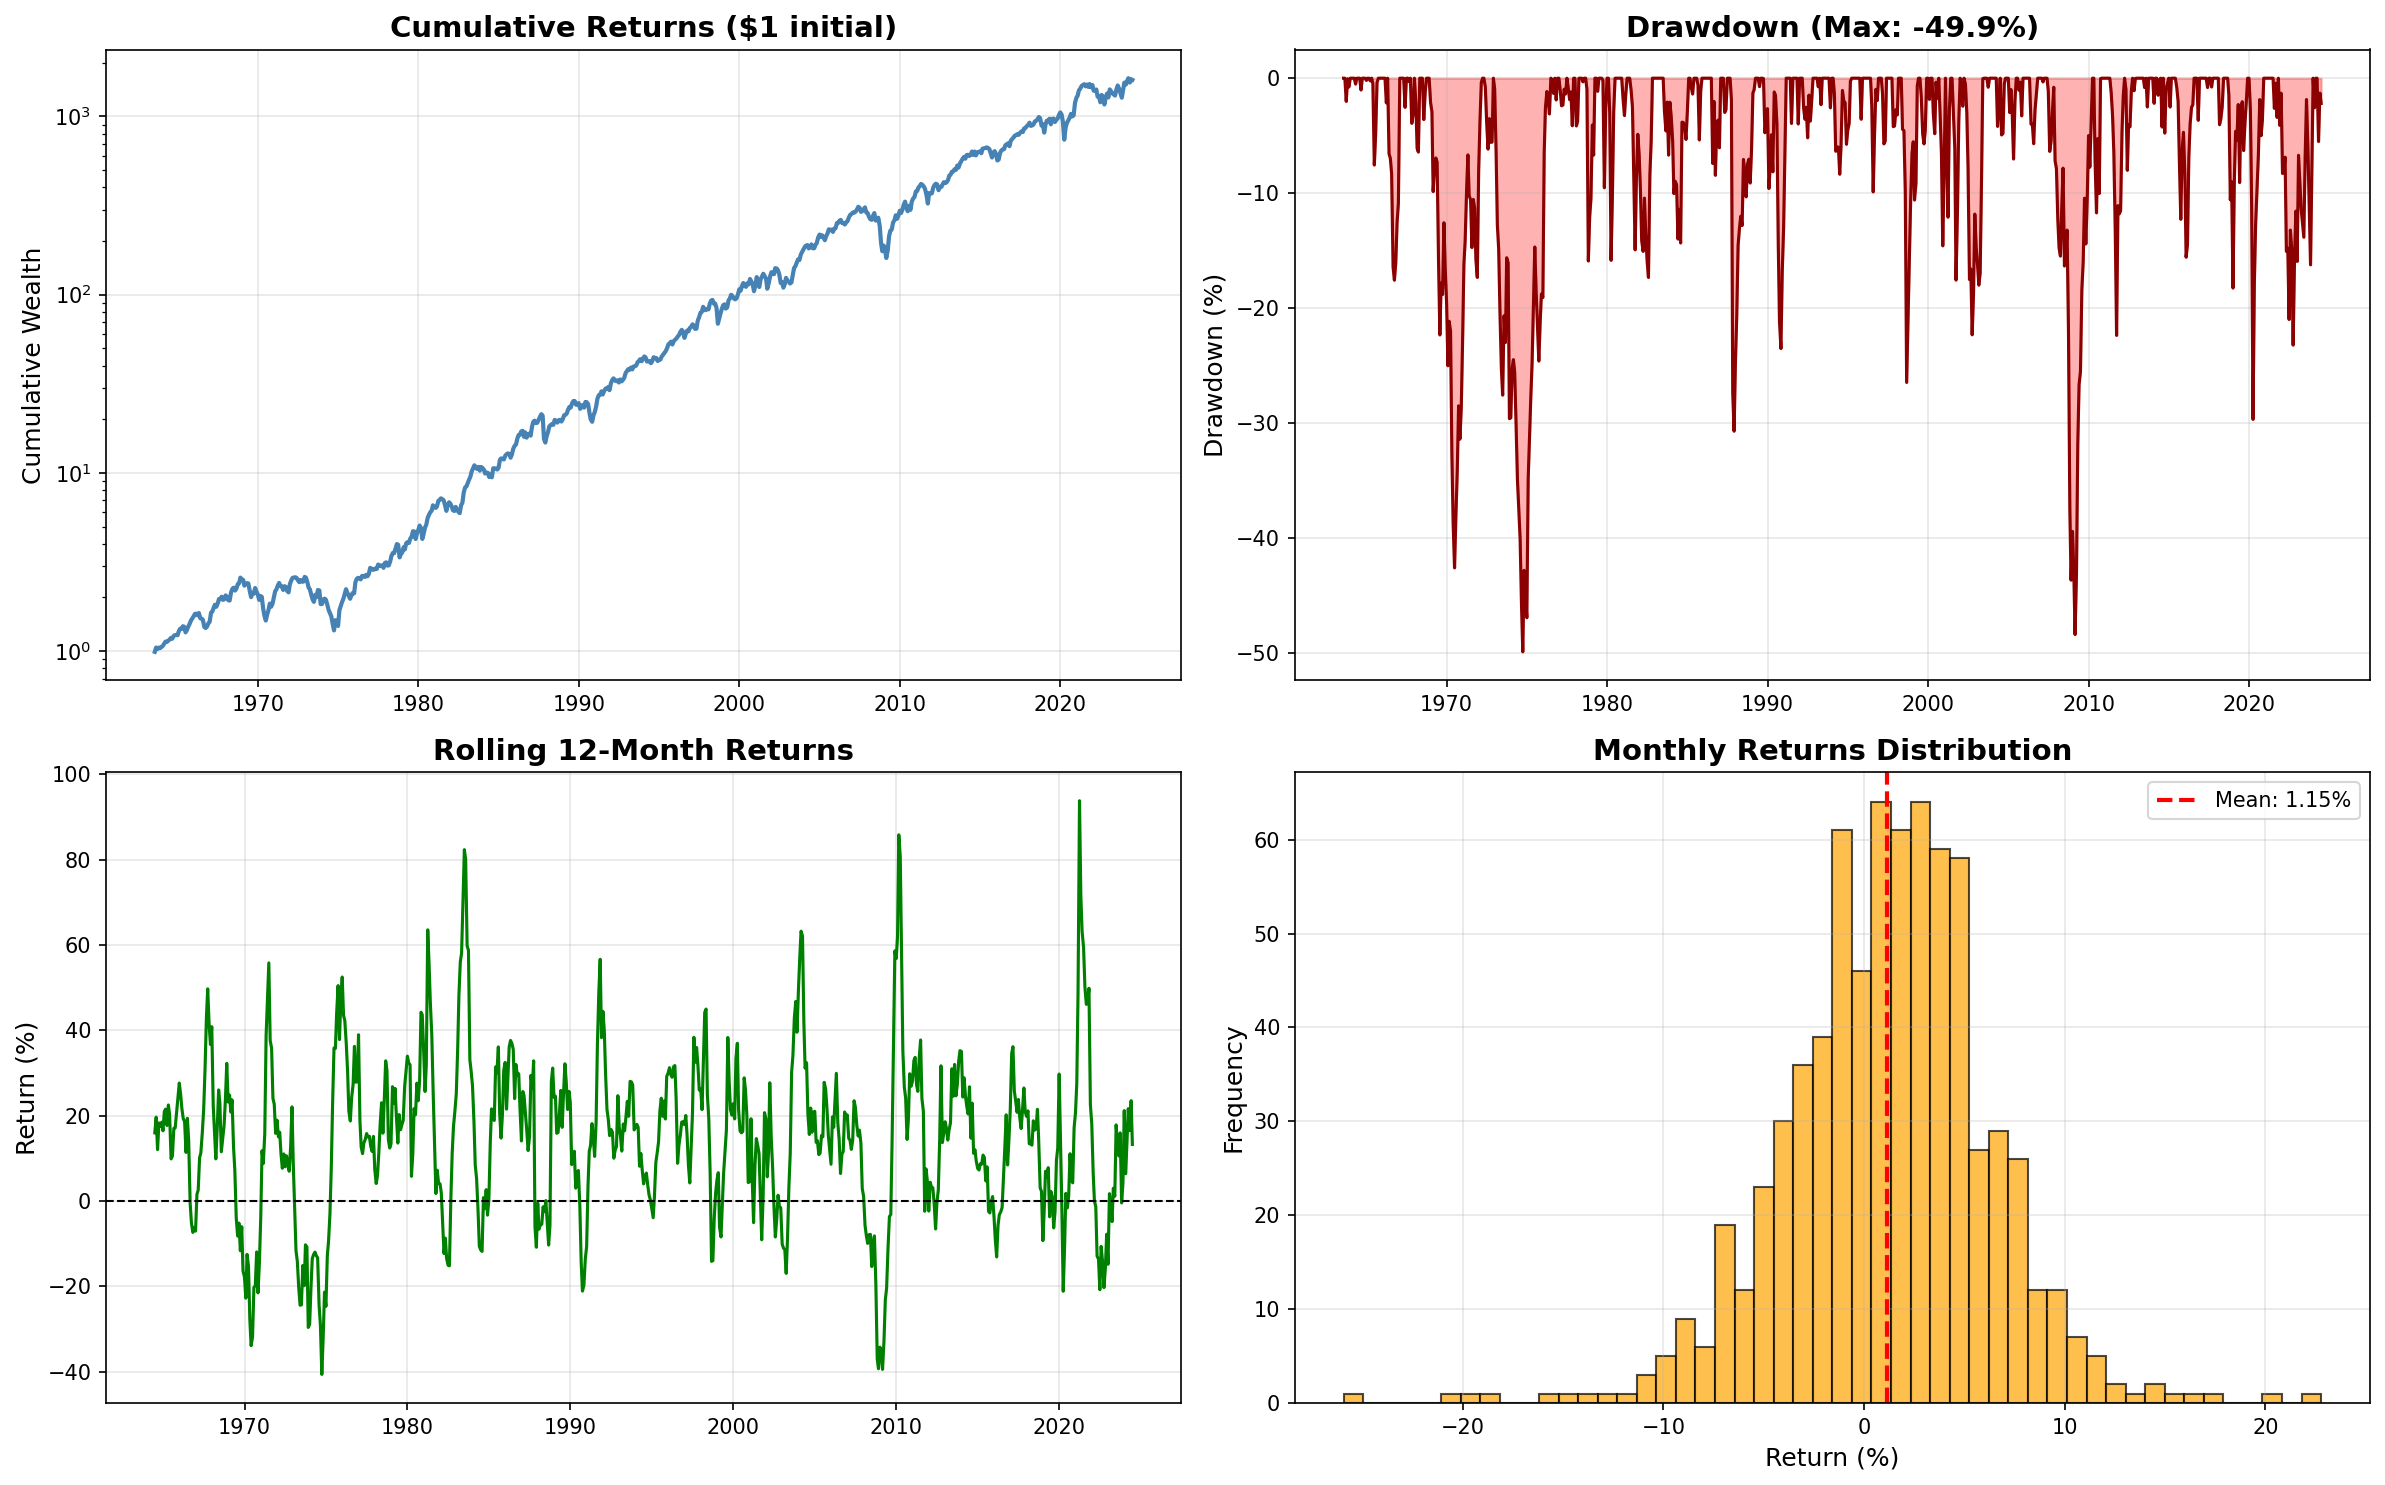


✅ Plot sauvegardé : data/ml_data/market/validation_plot.png


In [8]:
# ════════════════════════════════════════════════════════════════════════════
# ANALYSE & VALIDATION : MARKET RETURNS NYSE P20 EW
# ════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. CHARGER LE BENCHMARK
market = pd.read_parquet('data/ml_data/market/market_returns_ew_nys80.parquet')
market['date'] = pd.to_datetime(market['date'])
market.set_index('date', inplace=True)
market.sort_index(inplace=True)

print("="*80)
print("📊 VALIDATION MARKET BENCHMARK NYSE P20 EW")
print("="*80)

# 2. STATS DESCRIPTIVES
print(f"\n📅 Période : {market.index.min().date()} → {market.index.max().date()}")
print(f"📈 Total months : {len(market):,}")
print(f"📈 Missing values : {market['ret_market_ew'].isnull().sum()}")

ret = market['ret_market_ew'].dropna()
print(f"\n📊 STATISTIQUES MENSUELLES :")
print(f"   • Mean       : {ret.mean()*100:.2f}% per month ({ret.mean()*12*100:.2f}% annualized arithmetic)")
print(f"   • Median     : {ret.median()*100:.2f}%")
print(f"   • Std        : {ret.std()*100:.2f}% ({ret.std()*np.sqrt(12)*100:.2f}% annualized)")
print(f"   • Min        : {ret.min()*100:.2f}%")
print(f"   • Max        : {ret.max()*100:.2f}%")
print(f"   • Skewness   : {ret.skew():.2f}")
print(f"   • Kurtosis   : {ret.kurtosis():.2f}")

# 3. PERFORMANCE ANNUALISÉE
cumret = (1 + ret).prod() - 1
n_years = len(ret) / 12
ann_ret = (1 + cumret) ** (1/n_years) - 1
ann_vol = ret.std() * np.sqrt(12)
sharpe = (ann_ret - 0.04) / ann_vol  # RF approx 4%

print(f"\n🎯 PERFORMANCE ANNUALISÉE ({n_years:.1f} years) :")
print(f"   • Cumulative : {cumret*100:.1f}%")
print(f"   • CAGR       : {ann_ret*100:.2f}%")
print(f"   • Volatility : {ann_vol*100:.2f}%")
print(f"   • Sharpe     : {sharpe:.2f}")

# 4. DRAWDOWN
cumulative = (1 + ret).cumprod()
running_max = cumulative.expanding().max()
drawdown = (cumulative - running_max) / running_max
max_dd = drawdown.min()
print(f"   • Max Drawdown : {max_dd*100:.2f}%")

# 5. COMPARAISON FAMA-FRENCH MKTRF
ff5 = pd.read_csv('data/factors/ff/FF5.csv')
ff5['dateff'] = pd.to_datetime(ff5['dateff']) + pd.offsets.MonthEnd(0)
ff5.set_index('dateff', inplace=True)
ff5_aligned = ff5.reindex(market.index)

corr = market['ret_market_ew'].corr(ff5_aligned['mktrf'])
print(f"\n🔗 CORRÉLATION avec FF MKTRF : {corr:.3f}")

# 6. STATS PAR DÉCENNIE
print(f"\n📊 PERFORMANCE PAR DÉCENNIE :")
market['decade'] = (market.index.year // 10) * 10
for decade in sorted(market['decade'].unique()):
    decade_ret = market[market['decade'] == decade]['ret_market_ew'].dropna()
    if len(decade_ret) > 0:
        decade_cumret = (1 + decade_ret).prod() - 1
        decade_n_years = len(decade_ret) / 12
        decade_ann = (1 + decade_cumret) ** (1/decade_n_years) - 1
        decade_vol = decade_ret.std() * np.sqrt(12)
        print(f"   • {decade}s : CAGR={decade_ann*100:>6.2f}%  Vol={decade_vol*100:>6.2f}%  n={len(decade_ret):>4}")

# 7. VISUALISATION
fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=150)

# A. Cumulative Returns
ax1 = axes[0, 0]
ax1.plot(cumulative.index, cumulative.values, linewidth=2, color='steelblue')
ax1.set_title('Cumulative Returns ($1 initial)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Cumulative Wealth', fontsize=12)
ax1.grid(alpha=0.3)
ax1.set_yscale('log')

# B. Drawdown
ax2 = axes[0, 1]
ax2.fill_between(drawdown.index, drawdown.values*100, 0, color='red', alpha=0.3)
ax2.plot(drawdown.index, drawdown.values*100, linewidth=1.5, color='darkred')
ax2.set_title(f'Drawdown (Max: {max_dd*100:.1f}%)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Drawdown (%)', fontsize=12)
ax2.grid(alpha=0.3)

# C. Rolling 12m Returns
ax3 = axes[1, 0]
rolling_12m = ret.rolling(12).apply(lambda x: (1+x).prod()-1, raw=False)
ax3.plot(rolling_12m.index, rolling_12m.values*100, linewidth=1.5, color='green')
ax3.axhline(0, color='black', linestyle='--', linewidth=1)
ax3.set_title('Rolling 12-Month Returns', fontsize=14, fontweight='bold')
ax3.set_ylabel('Return (%)', fontsize=12)
ax3.grid(alpha=0.3)

# D. Monthly Returns Distribution
ax4 = axes[1, 1]
ax4.hist(ret*100, bins=50, color='orange', edgecolor='black', alpha=0.7)
ax4.axvline(ret.mean()*100, color='red', linestyle='--', linewidth=2, label=f'Mean: {ret.mean()*100:.2f}%')
ax4.set_title('Monthly Returns Distribution', fontsize=14, fontweight='bold')
ax4.set_xlabel('Return (%)', fontsize=12)
ax4.set_ylabel('Frequency', fontsize=12)
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('data/ml_data/market/validation_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Plot sauvegardé : data/ml_data/market/validation_plot.png")
print("="*80)